# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge

In [2]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alphas = [0.1, 1.0, 10.0, 100.0]

for alpha in alphas:
    w = np.linalg.inv(x.T*x + alpha * I)*x.T*y
    w=w.ravel()

    mse = np.mean(np.square(y - (x * w.T)))
    print(f"Alpha: {alpha:<5} | Weights: {np.array(w)}")


Alpha: 0.1   | Weights: [[-101.72397081    1.16978757]]
Alpha: 1.0   | Weights: [[-20.59044706   0.71048616]]
Alpha: 10.0  | Weights: [[-2.29106262  0.60688107]]
Alpha: 100.0 | Weights: [[-0.22873     0.59509096]]


## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results.

In [3]:
def sgd(X, y, alpha, lr=0.00001, epochs=10):
    m, n = X.shape
    w = np.zeros((n, 1))

    for _ in range(epochs):
        for i in range(m):
            xi = X[i, :]
            yi = y[i, 0]

            prediction = xi * w
            error = prediction - yi

            gradient = xi.T * error
            l1_penalty = alpha * np.sign(w)
            l1_penalty[0] = 0

            w = w - lr * (gradient + l1_penalty)
    return w.ravel()

In [4]:
from sklearn.linear_model import Lasso

In [10]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alpha = 0.1


w_sgd = sgd(x, y, alpha)

lasso_model = Lasso(alpha=alpha, fit_intercept=False, max_iter=1000)
lasso_model.fit(np.array(x), y)
w_sklearn = lasso_model.coef_

print(f"Weights SGD:     {np.array(w_sgd)}")
print(f"Weights Sklearn: {w_sklearn}")


Weights SGD:     [[0.00088956 0.60333151]]
Weights Sklearn: [-168.19471366    1.54607814]


## 3. Extend the Fisher's classifier

Write numpy code that performs Fisher classification using all the features of Iris data. Choose species nr 1 and 2 as two classes. Plot original data and their projection. Using obtained model classify the flower with the folowing features: [6.45, 2.85, 4.25, 1.25].

Fisher Weights: [ 0.46106601 -0.88736584]
New flower projection: -0.7974 (Threshold: -1.4662)
Classification: Species 1


/tmp/ipykernel_9026/3953291960.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  val_proj = float(new_proj)
/tmp/ipykernel_9026/3953291960.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  val_thresh = float(threshold)


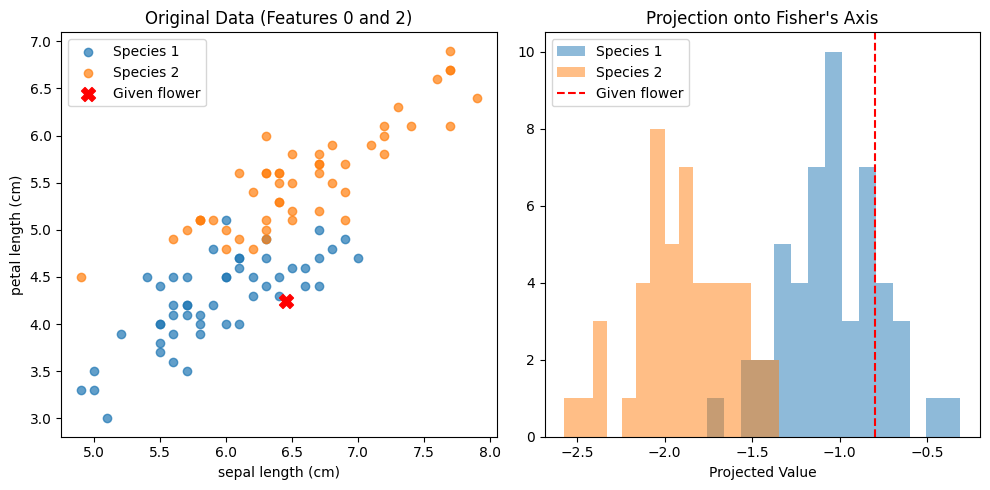

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[50:150, [0, 2]]
y = iris.target[50:150]

class1 = X[y == 1]
class2 = X[y == 2]

m1 = np.mean(class1, axis=0)
m2 = np.mean(class2, axis=0)

S1 = (class1 - m1).T @ (class1 - m1)
S2 = (class2 - m2).T @ (class2 - m2)
Sw = S1 + S2

w = np.linalg.inv(Sw) @ (m1 - m2).reshape(-1, 1)
w = w / np.linalg.norm(w)

proj1 = class1 @ w
proj2 = class2 @ w

full_flower_data = [6.45, 2.85, 4.25, 1.25]
new_flower = np.array([full_flower_data[0], full_flower_data[2]])

new_proj = new_flower @ w

threshold = (m1 @ w + m2 @ w) / 2
prediction = 1 if new_proj > threshold else 2

print(f"Fisher Weights: {w.ravel()}")

val_proj = float(new_proj)
val_thresh = float(threshold)

print(f"New flower projection: {val_proj:.4f} (Threshold: {val_thresh:.4f})")
print(f"Classification: Species {prediction}")

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(class1[:, 0], class1[:, 1], label='Species 1', alpha=0.7)
plt.scatter(class2[:, 0], class2[:, 1], label='Species 2', alpha=0.7)
plt.scatter(new_flower[0], new_flower[1], color='red', marker='X', s=100, label='Given flower')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[2])
plt.title("Original Data (Features 0 and 2)")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(np.array(proj1), bins=15, alpha=0.5, label='Species 1')
plt.hist(np.array(proj2), bins=15, alpha=0.5, label='Species 2')
plt.axvline(x=val_proj, color='red', linestyle='--', label='Given flower')
plt.title("Projection onto Fisher's Axis")
plt.xlabel("Projected Value")
plt.legend()

plt.tight_layout()
plt.show()